# Chapter 14: Shape Analysis

Source span: printed pages 303-348; PDF pages 317-361. The source PDF was used only for orientation: chapter order, terminology, and the main constructions. The prose, examples, diagrams, code, and artifacts here are original course material.

## Chapter Goal

Shape analysis asks for statistics of landmark configurations after nuisance transformations have been removed. For planar landmarks, the computation has a directional-statistics form:

1. translate landmarks to their centroid,
2. rotate into Helmert coordinates that discard the centroid direction,
3. divide by size to land on a complex unit sphere,
4. quotient out the remaining complex phase, which represents planar rotation.

The chapter is therefore not just about matching outlines. It replaces an ordinary Euclidean data table by preshapes on a sphere and shapes in complex projective space. This notebook makes each identification executable, then checks the invariants that should survive translation, scale, and rotation.


## Computational Translation Guide

| Book concept | Computational object in this notebook | What must be invariant |
|---|---|---|
| landmark configuration | a complex vector `z0`, one complex number per landmark | relabeling is not removed unless stated |
| centering | subtract the complex centroid or multiply by a Helmert submatrix | translation |
| Helmertized landmarks | `u = H @ z0`, where rows of `H` are orthonormal and perpendicular to the all-ones vector | translation and redundant centroid direction |
| preshape | `z = u / ||u||` on a complex unit sphere | translation and scale |
| shape | equivalence class `[z] = {exp(i theta) z}` in complex projective space | translation, scale, and rotation |
| Procrustes distance | a function of `abs(<z1, z2>)` | similarity transformations of either input |
| triangle shape sphere | Hopf/Kendall map from `CP^1` to `S^2` | phase invariance and unit-sphere coordinates |
| tangent shape PCA | horizontal tangent vectors at a mean preshape | tangent vectors orthogonal to the mean axis |
| complex directional models | model choice on `CP^(k-2)` or on the triangle sphere | density unchanged by phase multiplication |

The important computational habit is to name the sample space before fitting a statistic. A mean of raw coordinates answers a different question from a Procrustes mean of shapes, even if both start from the same landmark matrix.


## Chapter Storyboard

This pass implements the following visual sequence.

1. **Landmark centering, Helmertization, and preshape normalization.** A static pipeline shows how raw configurations that look different become the same point on the preshape sphere up to phase.
2. **Procrustes alignment.** A before/after overlay shows why the distance depends on the modulus of the complex inner product, not on the absolute orientation of either drawing.
3. **Kendall triangle shape sphere.** An interactive Plotly sphere uses the Hopf map to place triangle shapes on `S^2`; flat triangles sit on the equator and mirror images cross hemispheres.
4. **Tangent shape PCA.** A concentrated synthetic sample is projected to a horizontal tangent space at its Procrustes mean, then principal directions are drawn back as deformation modes.
5. **Complex directional model routing.** A small graph routes shape data to triangle-sphere models, complex Bingham/Watson models, angular Gaussian robustness, or tangent approximations according to the geometry.

The source chapter includes examples and data tables; this notebook intentionally uses small synthetic configurations so that the invariance claims can be checked directly without copying source data.


In [1]:
from pathlib import Path
import sys


def find_book_root(start: Path) -> Path:
    '''Find the Directional-Statistics course root from a notebook or repo cwd.'''
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (
            (candidate / "AGENTS.md").exists()
            and (candidate / "scripts" / "validate_dirstats_course.py").exists()
            and (candidate / "utils").exists()
        ):
            return candidate
        nested = candidate / "Directional-Statistics"
        if (
            (nested / "AGENTS.md").exists()
            and (nested / "scripts" / "validate_dirstats_course.py").exists()
            and (nested / "utils").exists()
        ):
            return nested
    raise RuntimeError("Could not locate the Directional-Statistics course root")


BOOK_ROOT = find_book_root(Path.cwd())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.validation import assert_artifacts

TOPIC = "chapter-14"
source_span = {"printed_pages": "303-348", "pdf_pages": "317-361"}
BOOK_ROOT, source_span


(WindowsPath('D:/Geometry/Directional-Statistics'),
 {'printed_pages': '303-348', 'pdf_pages': '317-361'})

In [2]:
import math

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go

np.set_printoptions(precision=5, suppress=True)
rng = np.random.default_rng(20260512)

COLORS = {
    "raw": "#3b6ea8",
    "transformed": "#d1495b",
    "aligned": "#2a9d8f",
    "mean": "#1f2937",
    "mode_a": "#7c3aed",
    "mode_b": "#f59e0b",
}


## 1. From Landmarks To Preshape

A planar configuration with `k` landmarks can be stored as a complex vector. Centering removes the all-ones direction. The Helmert submatrix does the same job in an orthonormal coordinate system: its rows are perpendicular to the all-ones vector, so `H @ (z0 + c)` equals `H @ z0` for every complex translation `c`.

After Helmertization, size is removed by dividing by the Euclidean norm. The result is a preshape on a unit sphere in complex coordinates. A planar rotation still multiplies every coordinate by the same complex phase, so a shape is the whole phase orbit of a preshape rather than one preferred representative.


In [3]:
def as_complex(points: np.ndarray) -> np.ndarray:
    points = np.asarray(points, dtype=float)
    if points.ndim != 2 or points.shape[1] != 2:
        raise ValueError("points must be an array with shape (k, 2)")
    return points[:, 0] + 1j * points[:, 1]


def as_points(z: np.ndarray) -> np.ndarray:
    z = np.asarray(z, dtype=complex)
    return np.column_stack([z.real, z.imag])


def helmert_submatrix(k: int) -> np.ndarray:
    '''Return the last k-1 rows of the standard real Helmert matrix.'''
    H = np.zeros((k - 1, k), dtype=float)
    for r in range(1, k):
        H[r - 1, :r] = 1.0 / math.sqrt(r * (r + 1))
        H[r - 1, r] = -r / math.sqrt(r * (r + 1))
    return H


def center_complex(z0: np.ndarray) -> np.ndarray:
    z0 = np.asarray(z0, dtype=complex)
    return z0 - z0.mean()


def preshape(z0: np.ndarray, H: np.ndarray | None = None) -> np.ndarray:
    z0 = np.asarray(z0, dtype=complex)
    H = helmert_submatrix(len(z0)) if H is None else H
    u = H @ z0
    norm = np.linalg.norm(u)
    if norm <= 1e-14:
        raise ValueError("degenerate configuration has zero centroid size")
    return u / norm


def landmarks_from_preshape(z: np.ndarray, H: np.ndarray) -> np.ndarray:
    '''Choose the centered landmark representative whose Helmert coordinates are z.'''
    return H.conj().T @ np.asarray(z, dtype=complex)


def similarity_transform(z0: np.ndarray, *, translation=0.0 + 0.0j, scale=1.0, rotation=0.0) -> np.ndarray:
    return translation + scale * np.exp(1j * rotation) * np.asarray(z0, dtype=complex)


def normalize_phase_to_reference(reference: np.ndarray, z: np.ndarray) -> np.ndarray:
    inner = np.vdot(reference, z)
    if abs(inner) <= 1e-14:
        return z.copy()
    return np.exp(-1j * np.angle(inner)) * z


def procrustes_inner(z1: np.ndarray, z2: np.ndarray) -> complex:
    return np.vdot(z1, z2)


def procrustes_distance(z1: np.ndarray, z2: np.ndarray) -> float:
    '''Full Procrustes shape distance sqrt(1 - |<z1,z2>|^2).'''
    inner_abs = min(1.0, abs(procrustes_inner(z1, z2)))
    return float(np.sqrt(max(0.0, 1.0 - inner_abs**2)))


def shape_angle(z1: np.ndarray, z2: np.ndarray) -> float:
    inner_abs = min(1.0, abs(procrustes_inner(z1, z2)))
    return float(np.arccos(inner_abs))


def hopf_kendall(z: np.ndarray) -> np.ndarray:
    '''Hopf/Kendall map CP^1 -> S^2 for a two-complex-coordinate preshape.'''
    z = np.asarray(z, dtype=complex)
    if z.shape != (2,):
        raise ValueError("triangle preshapes have exactly two Helmert coordinates")
    z = z / np.linalg.norm(z)
    cross = z[0] * np.conj(z[1])
    return np.array([2 * cross.real, abs(z[0]) ** 2 - abs(z[1]) ** 2, 2 * cross.imag], dtype=float)


def procrustes_mean(preshapes: np.ndarray, max_iter: int = 50) -> np.ndarray:
    '''Dominant-eigenvector Procrustes mean with phase stabilization.'''
    Z = np.asarray(preshapes, dtype=complex)
    S = Z.conj().T @ Z
    values, vectors = np.linalg.eigh(S)
    mean = vectors[:, np.argmax(values)]
    mean = mean / np.linalg.norm(mean)
    anchor = Z[0]
    mean = normalize_phase_to_reference(anchor, mean)
    for _ in range(max_iter):
        aligned = np.array([normalize_phase_to_reference(mean, z) for z in Z])
        next_mean = aligned.mean(axis=0)
        next_mean = next_mean / np.linalg.norm(next_mean)
        next_mean = normalize_phase_to_reference(mean, next_mean)
        if np.linalg.norm(next_mean - mean) < 1e-12:
            break
        mean = next_mean
    return mean


def tangent_log(mean: np.ndarray, z: np.ndarray) -> np.ndarray:
    '''Horizontal sphere log map after optimal phase alignment to mean.'''
    aligned = normalize_phase_to_reference(mean, z)
    cos_theta = float(np.clip(np.vdot(mean, aligned).real, -1.0, 1.0))
    theta = float(np.arccos(cos_theta))
    residual = aligned - cos_theta * mean
    sin_theta = np.linalg.norm(residual)
    if sin_theta <= 1e-12:
        return residual
    return (theta / sin_theta) * residual


def tangent_exp(mean: np.ndarray, v: np.ndarray) -> np.ndarray:
    norm_v = float(np.linalg.norm(v))
    if norm_v <= 1e-12:
        return mean.copy()
    z = np.cos(norm_v) * mean + np.sin(norm_v) * v / norm_v
    return z / np.linalg.norm(z)


def flatten_complex(z: np.ndarray) -> np.ndarray:
    return np.concatenate([np.asarray(z).real, np.asarray(z).imag])


def unflatten_complex(x: np.ndarray) -> np.ndarray:
    half = len(x) // 2
    return np.asarray(x[:half]) + 1j * np.asarray(x[half:])


def closed_plot(ax, z: np.ndarray, *, color: str, label: str, lw: float = 2.0, alpha: float = 1.0, marker: str = "o") -> None:
    pts = as_points(z)
    closed = np.vstack([pts, pts[0]])
    ax.plot(closed[:, 0], closed[:, 1], color=color, lw=lw, alpha=alpha, marker=marker, ms=4, label=label)
    ax.set_aspect("equal", adjustable="datalim")
    ax.axhline(0, color="#e5e7eb", lw=0.8, zorder=0)
    ax.axvline(0, color="#e5e7eb", lw=0.8, zorder=0)


base_shape = as_complex(
    np.array([
        [-1.65, 0.05],
        [-1.05, 0.82],
        [-0.18, 1.05],
        [0.78, 0.72],
        [1.42, 0.10],
        [0.88, -0.62],
        [0.05, -0.88],
        [-0.95, -0.58],
    ])
)
base_shape = center_complex(base_shape)
H8 = helmert_submatrix(len(base_shape))
base_preshape = preshape(base_shape, H8)

pipeline_variants = {
    "original": base_shape,
    "translated": similarity_transform(base_shape, translation=2.4 - 1.6j),
    "scaled rotated": similarity_transform(base_shape, scale=1.85, rotation=0.86),
    "combined": similarity_transform(base_shape, translation=-1.8 + 1.1j, scale=0.62, rotation=-1.15),
}
variant_preshapes = {name: preshape(z, H8) for name, z in pipeline_variants.items()}
variant_shape_distances = {name: procrustes_distance(base_preshape, z) for name, z in variant_preshapes.items()}

helmert_diagnostics = {
    "helmert_orthogonality_error": float(np.linalg.norm(H8 @ H8.T - np.eye(H8.shape[0]))),
    "helmert_translation_error": float(np.linalg.norm(H8 @ np.ones(len(base_shape)))),
    "centered_vs_helmert_translation_error": float(np.linalg.norm(H8 @ base_shape - H8 @ center_complex(base_shape))),
    "base_preshape_norm": float(np.linalg.norm(base_preshape)),
    "max_similarity_shape_distance": float(max(variant_shape_distances.values())),
}
helmert_diagnostics


{'helmert_orthogonality_error': 4.2255205477654283e-16,
 'helmert_translation_error': 2.0014830212433605e-16,
 'centered_vs_helmert_translation_error': 0.0,
 'base_preshape_norm': 1.0,
 'max_similarity_shape_distance': 1.4901161193847656e-08}

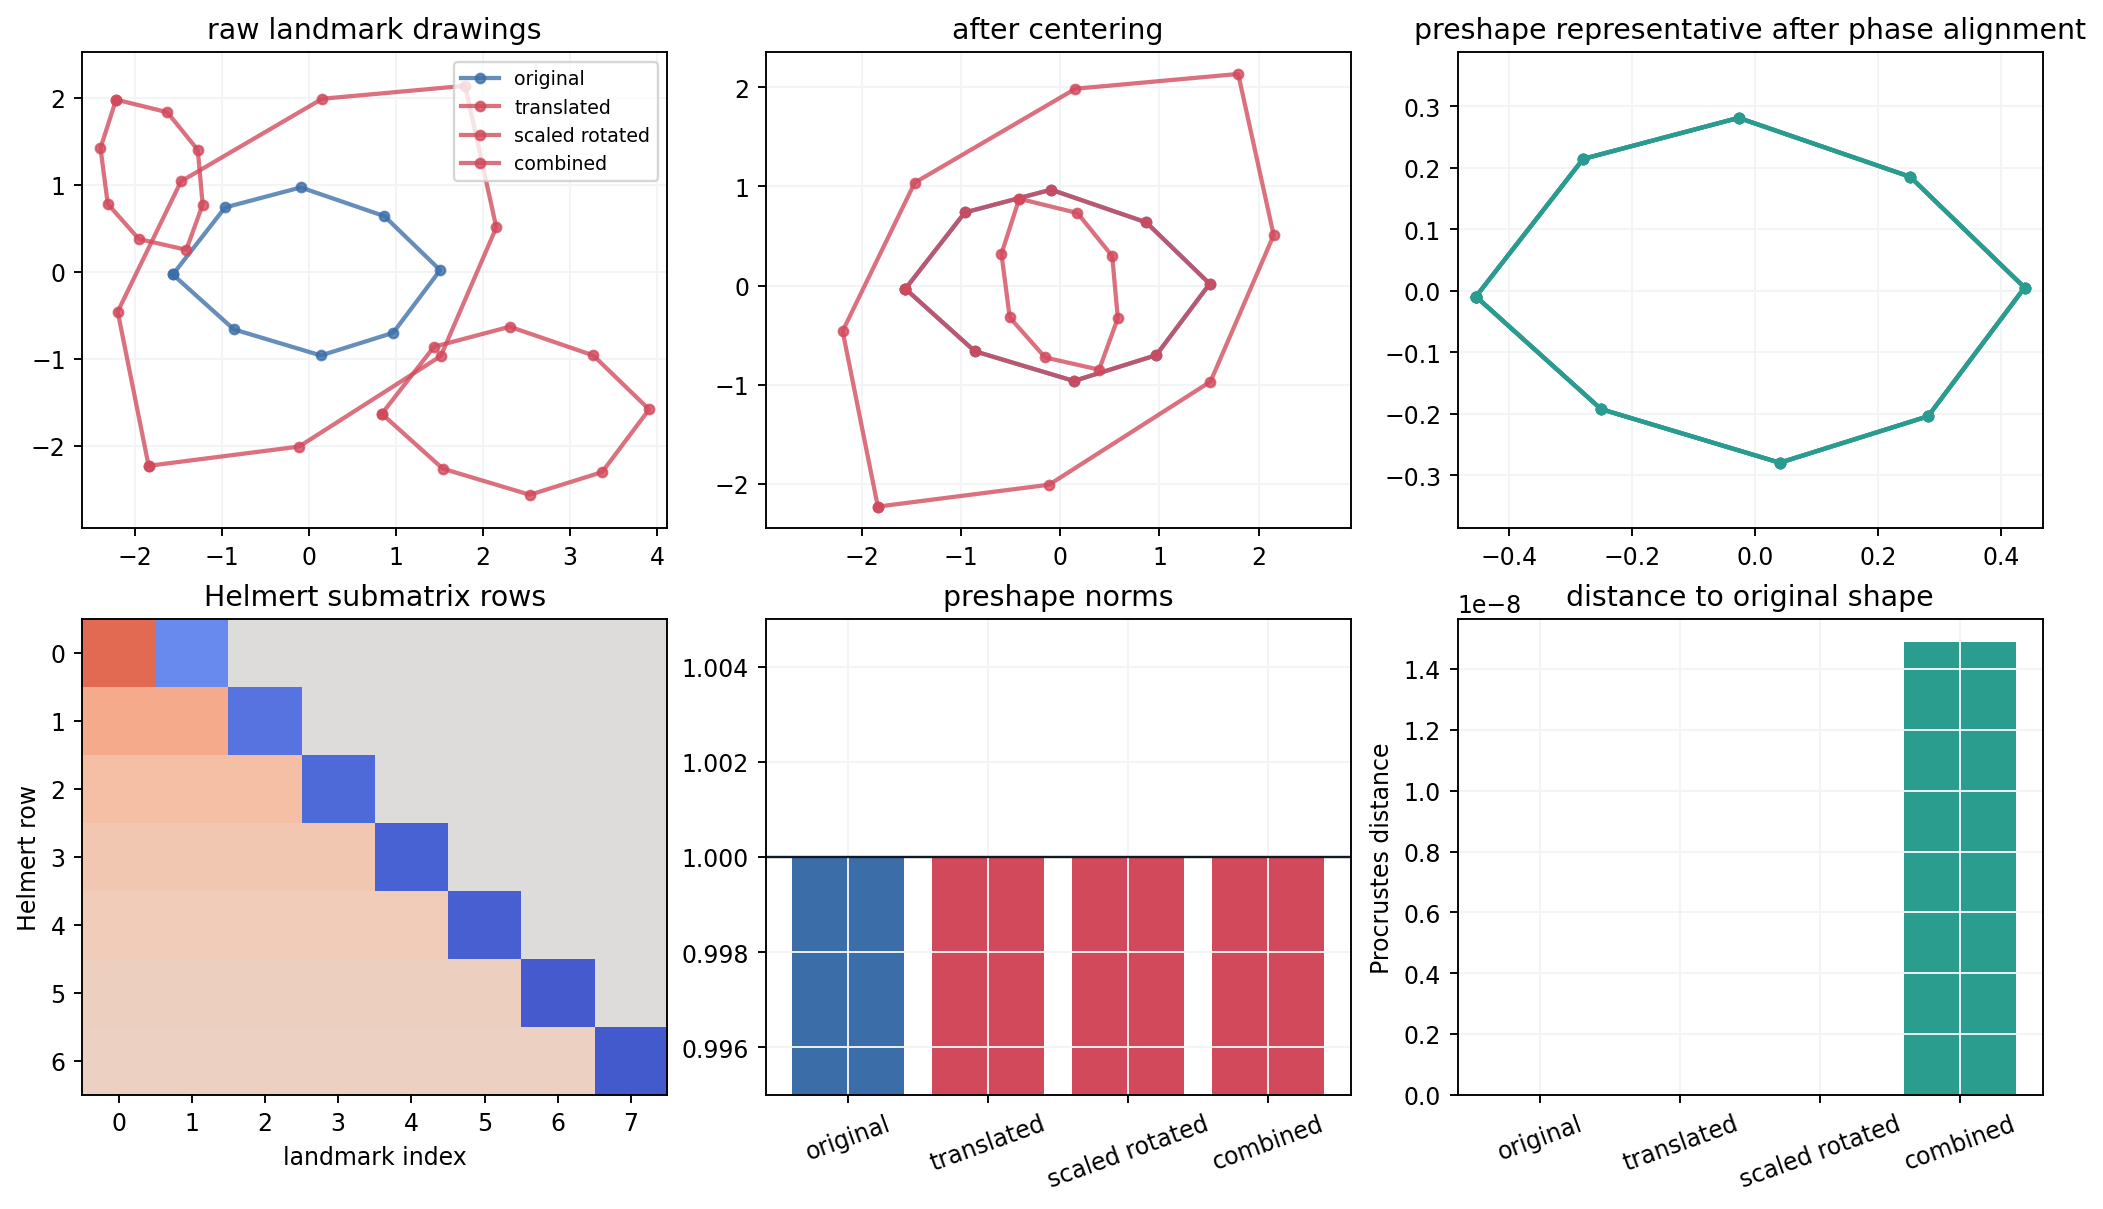

{'helmert_orthogonality_error': 4.2255205477654283e-16,
 'helmert_translation_error': 2.0014830212433605e-16,
 'centered_vs_helmert_translation_error': 0.0,
 'base_preshape_norm': 1.0,
 'max_similarity_shape_distance': 1.4901161193847656e-08}

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
axes = axes.ravel()

for name, z in pipeline_variants.items():
    color = COLORS["raw"] if name == "original" else COLORS["transformed"]
    closed_plot(axes[0], z, color=color, label=name, lw=1.8, alpha=0.78)
axes[0].set_title("raw landmark drawings")
axes[0].legend(fontsize=8, loc="upper right")

for name, z in pipeline_variants.items():
    color = COLORS["raw"] if name == "original" else COLORS["transformed"]
    closed_plot(axes[1], center_complex(z), color=color, label=name, lw=1.8, alpha=0.78)
axes[1].set_title("after centering")

for name, z in variant_preshapes.items():
    aligned = normalize_phase_to_reference(base_preshape, z)
    recovered = landmarks_from_preshape(aligned, H8)
    color = COLORS["raw"] if name == "original" else COLORS["aligned"]
    closed_plot(axes[2], recovered, color=color, label=name, lw=1.8, alpha=0.78)
axes[2].set_title("preshape representative after phase alignment")

axes[3].imshow(H8, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
axes[3].set_title("Helmert submatrix rows")
axes[3].set_xlabel("landmark index")
axes[3].set_ylabel("Helmert row")

names = list(variant_preshapes)
norms = [np.linalg.norm(variant_preshapes[name]) for name in names]
axes[4].bar(names, norms, color=[COLORS["raw"], COLORS["transformed"], COLORS["transformed"], COLORS["transformed"]])
axes[4].axhline(1.0, color="#111827", lw=1.0)
axes[4].set_ylim(0.995, 1.005)
axes[4].set_title("preshape norms")
axes[4].tick_params(axis="x", rotation=20)

shape_errors = [variant_shape_distances[name] for name in names]
axes[5].bar(names, shape_errors, color="#2a9d8f")
axes[5].set_title("distance to original shape")
axes[5].tick_params(axis="x", rotation=20)
axes[5].set_ylabel("Procrustes distance")

for ax in axes:
    if ax is not axes[3]:
        ax.grid(True, color="#f3f4f6", linewidth=0.8)

pipeline_path = save_matplotlib(fig, TOPIC, "pipeline", "landmark-centering-helmert-preshape.png", dpi=170)
plt.close(fig)
display_artifact(pipeline_path, width=920)
helmert_diagnostics


## 2. Procrustes Alignment And Distance

Once two configurations have been turned into preshapes, the remaining nuisance rotation is a common phase. The optimal phase is the one that makes the complex inner product real and nonnegative. The full Procrustes shape distance used here is

\[
 d_P([z_1],[z_2]) = \sqrt{1 - |\langle z_1, z_2\rangle|^2}.
\]

The modulus is the key. Translating, scaling, or rotating either raw configuration changes the drawing but not the shape distance. The overlay below intentionally shows both the misleading raw comparison and the aligned comparison.


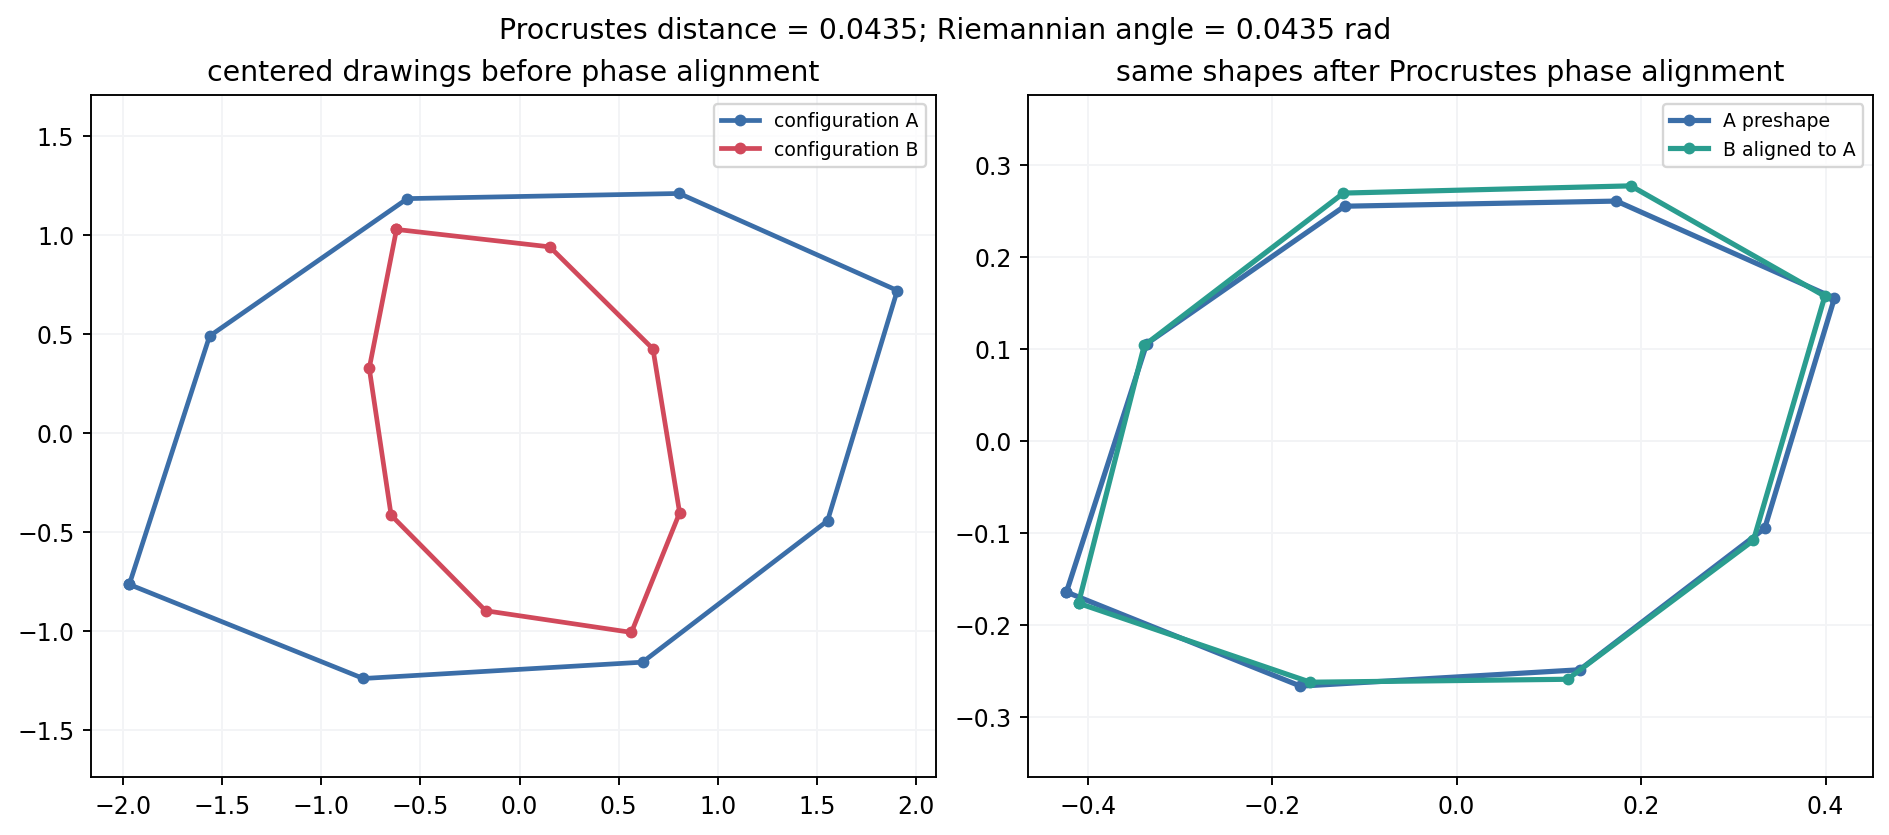

{'centered_raw_euclidean_gap': 5.044018546309557,
 'procrustes_shape_distance': 0.04349079899890499,
 'shape_riemannian_angle_radians': 0.04350452079049556,
 'procrustes_distance_invariance_error': 2.55351295663786e-15,
 'aligned_inner_product_imag_abs': 5.551115123125783e-17}

In [5]:
deformation = as_complex(
    np.array([
        [-0.10, 0.00],
        [-0.06, 0.10],
        [0.05, 0.14],
        [0.18, 0.06],
        [0.10, -0.03],
        [0.00, -0.12],
        [-0.08, -0.10],
        [-0.05, -0.02],
    ])
)
comparison_shape = center_complex(base_shape + deformation)
raw_a = similarity_transform(base_shape, translation=-1.7 + 1.4j, scale=1.35, rotation=0.35)
raw_b = similarity_transform(comparison_shape, translation=1.9 - 0.9j, scale=0.72, rotation=-1.05)
za = preshape(raw_a, H8)
zb = preshape(raw_b, H8)
zb_aligned = normalize_phase_to_reference(za, zb)
raw_distance = float(np.linalg.norm(center_complex(raw_a) - center_complex(raw_b)))
shape_distance = procrustes_distance(za, zb)
shape_riemannian_angle = shape_angle(za, zb)

raw_a2 = similarity_transform(base_shape, translation=3.0 - 2.0j, scale=0.48, rotation=1.7)
raw_b2 = similarity_transform(comparison_shape, translation=-0.3 + 1.8j, scale=2.1, rotation=-0.4)
invariant_distance_error = abs(procrustes_distance(za, zb) - procrustes_distance(preshape(raw_a2, H8), preshape(raw_b2, H8)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)
closed_plot(axes[0], center_complex(raw_a), color=COLORS["raw"], label="configuration A", lw=2.0)
closed_plot(axes[0], center_complex(raw_b), color=COLORS["transformed"], label="configuration B", lw=2.0)
axes[0].set_title("centered drawings before phase alignment")
axes[0].legend(fontsize=8)

closed_plot(axes[1], landmarks_from_preshape(za, H8), color=COLORS["raw"], label="A preshape", lw=2.2)
closed_plot(axes[1], landmarks_from_preshape(zb_aligned, H8), color=COLORS["aligned"], label="B aligned to A", lw=2.2)
axes[1].set_title("same shapes after Procrustes phase alignment")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.grid(True, color="#f3f4f6", linewidth=0.8)

fig.suptitle(f"Procrustes distance = {shape_distance:.4f}; Riemannian angle = {shape_riemannian_angle:.4f} rad", fontsize=12)
procrustes_path = save_matplotlib(fig, TOPIC, "procrustes", "procrustes-alignment-overlay.png", dpi=170)
plt.close(fig)
display_artifact(procrustes_path, width=900)

procrustes_diagnostics = {
    "centered_raw_euclidean_gap": raw_distance,
    "procrustes_shape_distance": shape_distance,
    "shape_riemannian_angle_radians": shape_riemannian_angle,
    "procrustes_distance_invariance_error": float(invariant_distance_error),
    "aligned_inner_product_imag_abs": float(abs(np.vdot(za, zb_aligned).imag)),
}
procrustes_diagnostics


## 3. Kendall Triangle Shape Sphere

For triangles, the shape space `CP^1` can be represented by an ordinary sphere. If a triangle preshape has two complex Helmert coordinates `(z1, z2)`, the Hopf/Kendall coordinates are

\[
(x,y,z) = \left(2\operatorname{Re}(z_1\overline{z_2}),
|z_1|^2-|z_2|^2,
2\operatorname{Im}(z_1\overline{z_2})\right).
\]

Multiplying the preshape by a common phase leaves these three coordinates unchanged. This is why the representation belongs to shape space rather than to oriented preshape space. In the interactive artifact, inspect where flat triangles, mirror images, and nearly equilateral triangles land.


In [6]:
def triangle(label: str, xy: list[tuple[float, float]]) -> dict:
    raw = as_complex(np.array(xy, dtype=float))
    z = preshape(raw, helmert_submatrix(3))
    return {"label": label, "raw": raw, "preshape": z, "sphere": hopf_kendall(z)}


triangles = [
    triangle("equilateral up", [(0, 0), (1, 0), (0.5, math.sqrt(3) / 2)]),
    triangle("equilateral down", [(0, 0), (1, 0), (0.5, -math.sqrt(3) / 2)]),
    triangle("flat middle", [(0, 0), (1, 0), (0.45, 0.0)]),
    triangle("right", [(0, 0), (1, 0), (0, 0.85)]),
    triangle("skinny", [(0, 0), (1, 0), (0.20, 0.16)]),
    triangle("obtuse", [(0, 0), (1, 0), (1.35, 0.38)]),
]
sphere_points = np.array([item["sphere"] for item in triangles])

u = np.linspace(0, 2 * np.pi, 96)
v = np.linspace(0, np.pi, 48)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))

phi = np.linspace(0, 2 * np.pi, 240)
equator = np.column_stack([np.cos(phi), np.sin(phi), np.zeros_like(phi)])

fig = go.Figure()
fig.add_trace(go.Surface(x=xs, y=ys, z=zs, opacity=0.18, colorscale=[[0, "#dbeafe"], [1, "#dbeafe"]], showscale=False, hoverinfo="skip", name="shape sphere"))
fig.add_trace(go.Scatter3d(x=equator[:, 0], y=equator[:, 1], z=equator[:, 2], mode="lines", line=dict(color="#4b5563", width=5), name="flat-triangle equator"))
fig.add_trace(
    go.Scatter3d(
        x=sphere_points[:, 0],
        y=sphere_points[:, 1],
        z=sphere_points[:, 2],
        mode="markers+text",
        marker=dict(size=7, color=["#16a34a", "#dc2626", "#4b5563", "#2563eb", "#f59e0b", "#7c3aed"]),
        text=[item["label"] for item in triangles],
        textposition="top center",
        hovertemplate="%{text}<br>x=%{x:.3f}<br>y=%{y:.3f}<br>z=%{z:.3f}<extra></extra>",
        name="triangle shapes",
    )
)
fig.update_layout(
    title="Kendall triangle shape sphere via the Hopf map",
    scene=dict(xaxis_title="2 Re(z1 conj(z2))", yaxis_title="|z1|^2 - |z2|^2", zaxis_title="2 Im(z1 conj(z2))", aspectmode="cube"),
    margin=dict(l=0, r=0, t=42, b=0),
    legend=dict(orientation="h", yanchor="bottom", y=0.01, xanchor="left", x=0.01),
)

shape_sphere_path = save_plotly_html(fig, TOPIC, "shape-sphere", "kendall-triangle-shape-sphere.html", include_plotlyjs=True)
display_artifact(shape_sphere_path, width="100%", height=560)

phase = np.exp(1j * 1.234)
shape_sphere_diagnostics = {
    "max_kendall_sphere_norm_error": float(np.max(np.abs(np.linalg.norm(sphere_points, axis=1) - 1.0))),
    "hopf_phase_invariance_error": float(np.linalg.norm(hopf_kendall(phase * triangles[0]["preshape"]) - triangles[0]["sphere"])),
    "flat_triangle_equator_abs_z": float(abs(triangles[2]["sphere"][2])),
    "triangle_labels": [item["label"] for item in triangles],
}
shape_sphere_diagnostics


{'max_kendall_sphere_norm_error': 2.220446049250313e-16,
 'hopf_phase_invariance_error': 2.5438405243138006e-16,
 'flat_triangle_equator_abs_z': 0.0,
 'triangle_labels': ['equilateral up',
  'equilateral down',
  'flat middle',
  'right',
  'skinny',
  'obtuse']}

## 4. Tangent Shape PCA And Deformation Modes

For concentrated shape data, the curved shape space can be approximated near a mean shape by a tangent space. The projection used here first aligns each preshape to the Procrustes mean, then uses a horizontal log vector. Horizontal means orthogonal to the mean preshape, so the vector changes shape rather than sliding along the phase orbit.

The PCA below is deliberately small: a synthetic sample of closed landmark chains is perturbed by two interpretable deformation patterns and then hidden under random translations, scales, and rotations. If the preceding geometry is working, the tangent PCA should recover shape variation rather than nuisance motion.


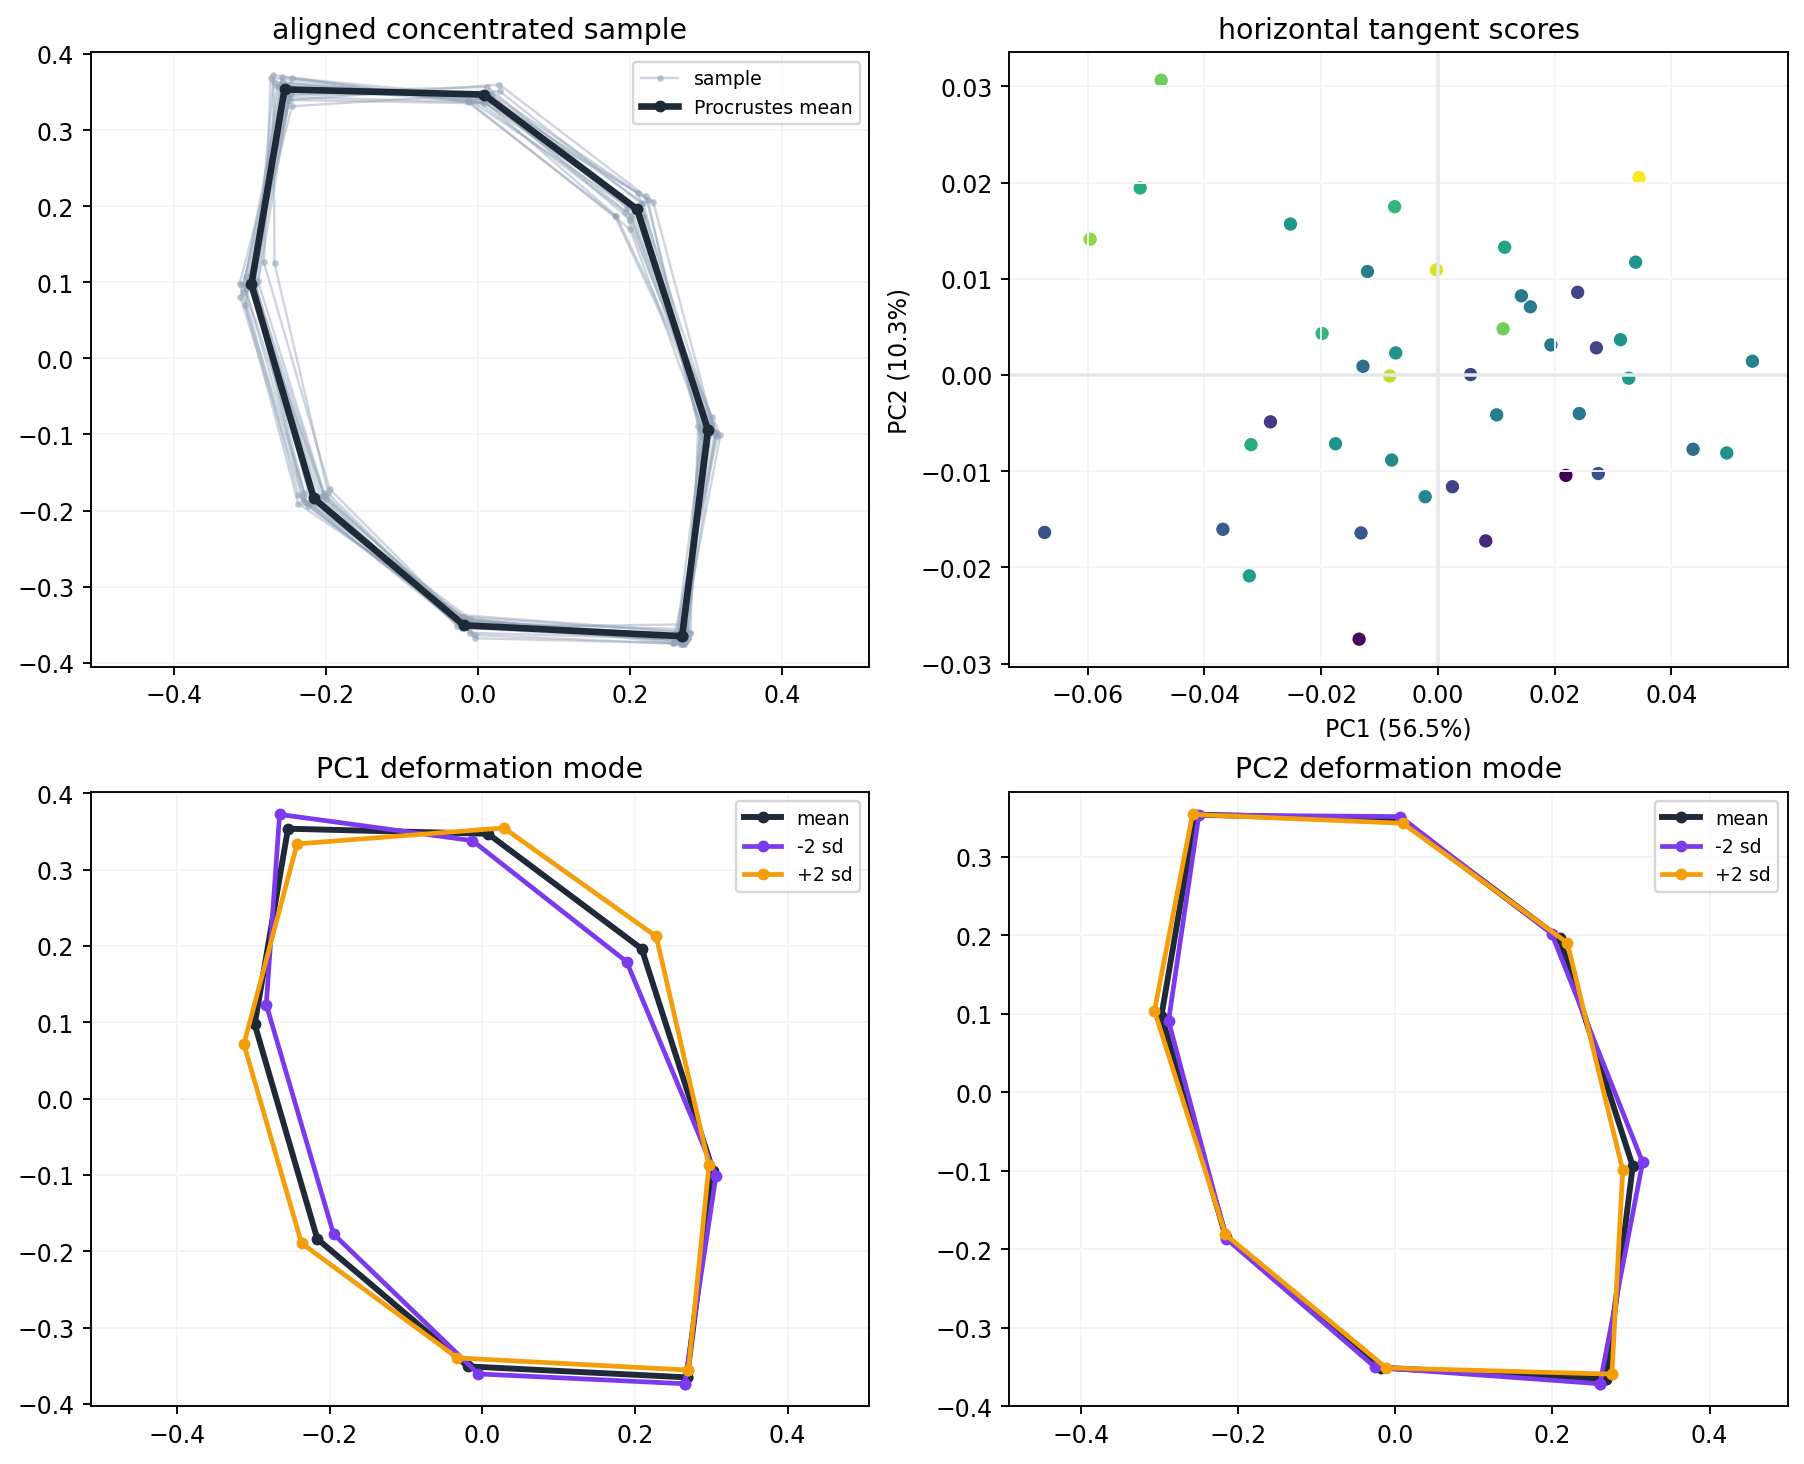

{'sample_size': 42,
 'mean_preshape_norm': 0.9999999999999999,
 'max_tangent_orthogonality_abs': 2.945992578940396e-16,
 'pca_explained_ratio_first_two': [0.5653789008278987, 0.10290518317338622],
 'pca_total_variance': 0.0015328626299780748}

In [7]:
def make_shape_sample(n: int = 42) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    k = len(base_shape)
    mode1 = as_complex(np.array([[-0.18, 0.00], [-0.12, 0.08], [-0.02, 0.08], [0.12, 0.04], [0.18, 0.00], [0.08, -0.05], [-0.02, -0.07], [-0.12, -0.04]]))
    mode2 = as_complex(np.array([[0.02, -0.10], [0.05, -0.02], [0.02, 0.10], [-0.06, 0.14], [-0.08, 0.04], [-0.03, -0.08], [0.03, -0.12], [0.05, -0.05]]))
    raw_shapes, preshapes, scores = [], [], []
    for _ in range(n):
        a = rng.normal(0, 0.55)
        b = rng.normal(0, 0.32)
        noise = as_complex(rng.normal(0, 0.025, size=(k, 2)))
        centered_shape = center_complex(base_shape + a * mode1 + b * mode2 + noise)
        hidden = similarity_transform(centered_shape, translation=rng.normal(0, 1.2) + 1j * rng.normal(0, 1.2), scale=rng.uniform(0.65, 1.75), rotation=rng.uniform(-np.pi, np.pi))
        raw_shapes.append(hidden)
        preshapes.append(preshape(hidden, H8))
        scores.append((a, b))
    return np.array(raw_shapes), np.array(preshapes), np.array(scores)


raw_sample, sample_preshapes, latent_scores = make_shape_sample()
mean_shape = procrustes_mean(sample_preshapes)
aligned_sample = np.array([normalize_phase_to_reference(mean_shape, z) for z in sample_preshapes])
tangent_vectors = np.array([tangent_log(mean_shape, z) for z in sample_preshapes])
tangent_matrix = np.array([flatten_complex(v) for v in tangent_vectors])
tangent_matrix -= tangent_matrix.mean(axis=0, keepdims=True)
U, singular_values, Vt = np.linalg.svd(tangent_matrix, full_matrices=False)
variances = singular_values**2 / (len(tangent_matrix) - 1)
explained_ratio = variances / variances.sum()
pc_scores = tangent_matrix @ Vt.T


def pca_mode_preshape(mode_index: int, sign: int) -> np.ndarray:
    amplitude = 2.0 * float(np.std(pc_scores[:, mode_index], ddof=1))
    v = sign * amplitude * unflatten_complex(Vt[mode_index])
    v = v - mean_shape * np.vdot(mean_shape, v)
    return tangent_exp(mean_shape, v)


fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.5), constrained_layout=True)

for idx, z in enumerate(aligned_sample[:18]):
    closed_plot(axes[0, 0], landmarks_from_preshape(z, H8), color="#94a3b8", label="sample" if idx == 0 else "", lw=1.0, alpha=0.45, marker=".")
closed_plot(axes[0, 0], landmarks_from_preshape(mean_shape, H8), color=COLORS["mean"], label="Procrustes mean", lw=2.8)
axes[0, 0].set_title("aligned concentrated sample")
axes[0, 0].legend(fontsize=8)

axes[0, 1].scatter(pc_scores[:, 0], pc_scores[:, 1], c=latent_scores[:, 0], cmap="viridis", s=38, edgecolor="white", linewidth=0.5)
axes[0, 1].axhline(0, color="#e5e7eb")
axes[0, 1].axvline(0, color="#e5e7eb")
axes[0, 1].set_xlabel(f"PC1 ({explained_ratio[0]:.1%})")
axes[0, 1].set_ylabel(f"PC2 ({explained_ratio[1]:.1%})")
axes[0, 1].set_title("horizontal tangent scores")

for mode_index, ax in [(0, axes[1, 0]), (1, axes[1, 1])]:
    closed_plot(ax, landmarks_from_preshape(mean_shape, H8), color=COLORS["mean"], label="mean", lw=2.5)
    closed_plot(ax, landmarks_from_preshape(pca_mode_preshape(mode_index, -1), H8), color=COLORS["mode_a"], label="-2 sd", lw=2.0)
    closed_plot(ax, landmarks_from_preshape(pca_mode_preshape(mode_index, +1), H8), color=COLORS["mode_b"], label="+2 sd", lw=2.0)
    ax.set_title(f"PC{mode_index + 1} deformation mode")
    ax.legend(fontsize=8)

for ax in axes.ravel():
    ax.grid(True, color="#f3f4f6", linewidth=0.8)

tangent_path = save_matplotlib(fig, TOPIC, "tangent", "tangent-shape-pca-modes.png", dpi=170)
plt.close(fig)
display_artifact(tangent_path, width=900)

tangent_diagnostics = {
    "sample_size": int(len(sample_preshapes)),
    "mean_preshape_norm": float(np.linalg.norm(mean_shape)),
    "max_tangent_orthogonality_abs": float(np.max(np.abs([np.vdot(mean_shape, v) for v in tangent_vectors]))),
    "pca_explained_ratio_first_two": [float(explained_ratio[0]), float(explained_ratio[1])],
    "pca_total_variance": float(variances.sum()),
}
tangent_diagnostics


## 5. Complex Directional Model Routing

After preshape construction, the statistical model should respect the phase quotient. The routing diagram is a compact decision aid:

- Triangle shapes can be moved to the ordinary sphere and analyzed with spherical directional tools.
- General planar landmark shapes live in complex projective space, so phase-invariant complex models are natural.
- Complex Bingham models allow anisotropic concentration around axes in preshape space.
- Complex Watson models are a simpler rotationally symmetric special case around a modal shape.
- Complex angular Gaussian models are useful when scatter and outlier behavior matter more than a single isotropic concentration.
- Tangent normal approximations are local tools for concentrated samples, not global shape distributions.

Each arrow records a geometric condition that must hold before a model is sensible.


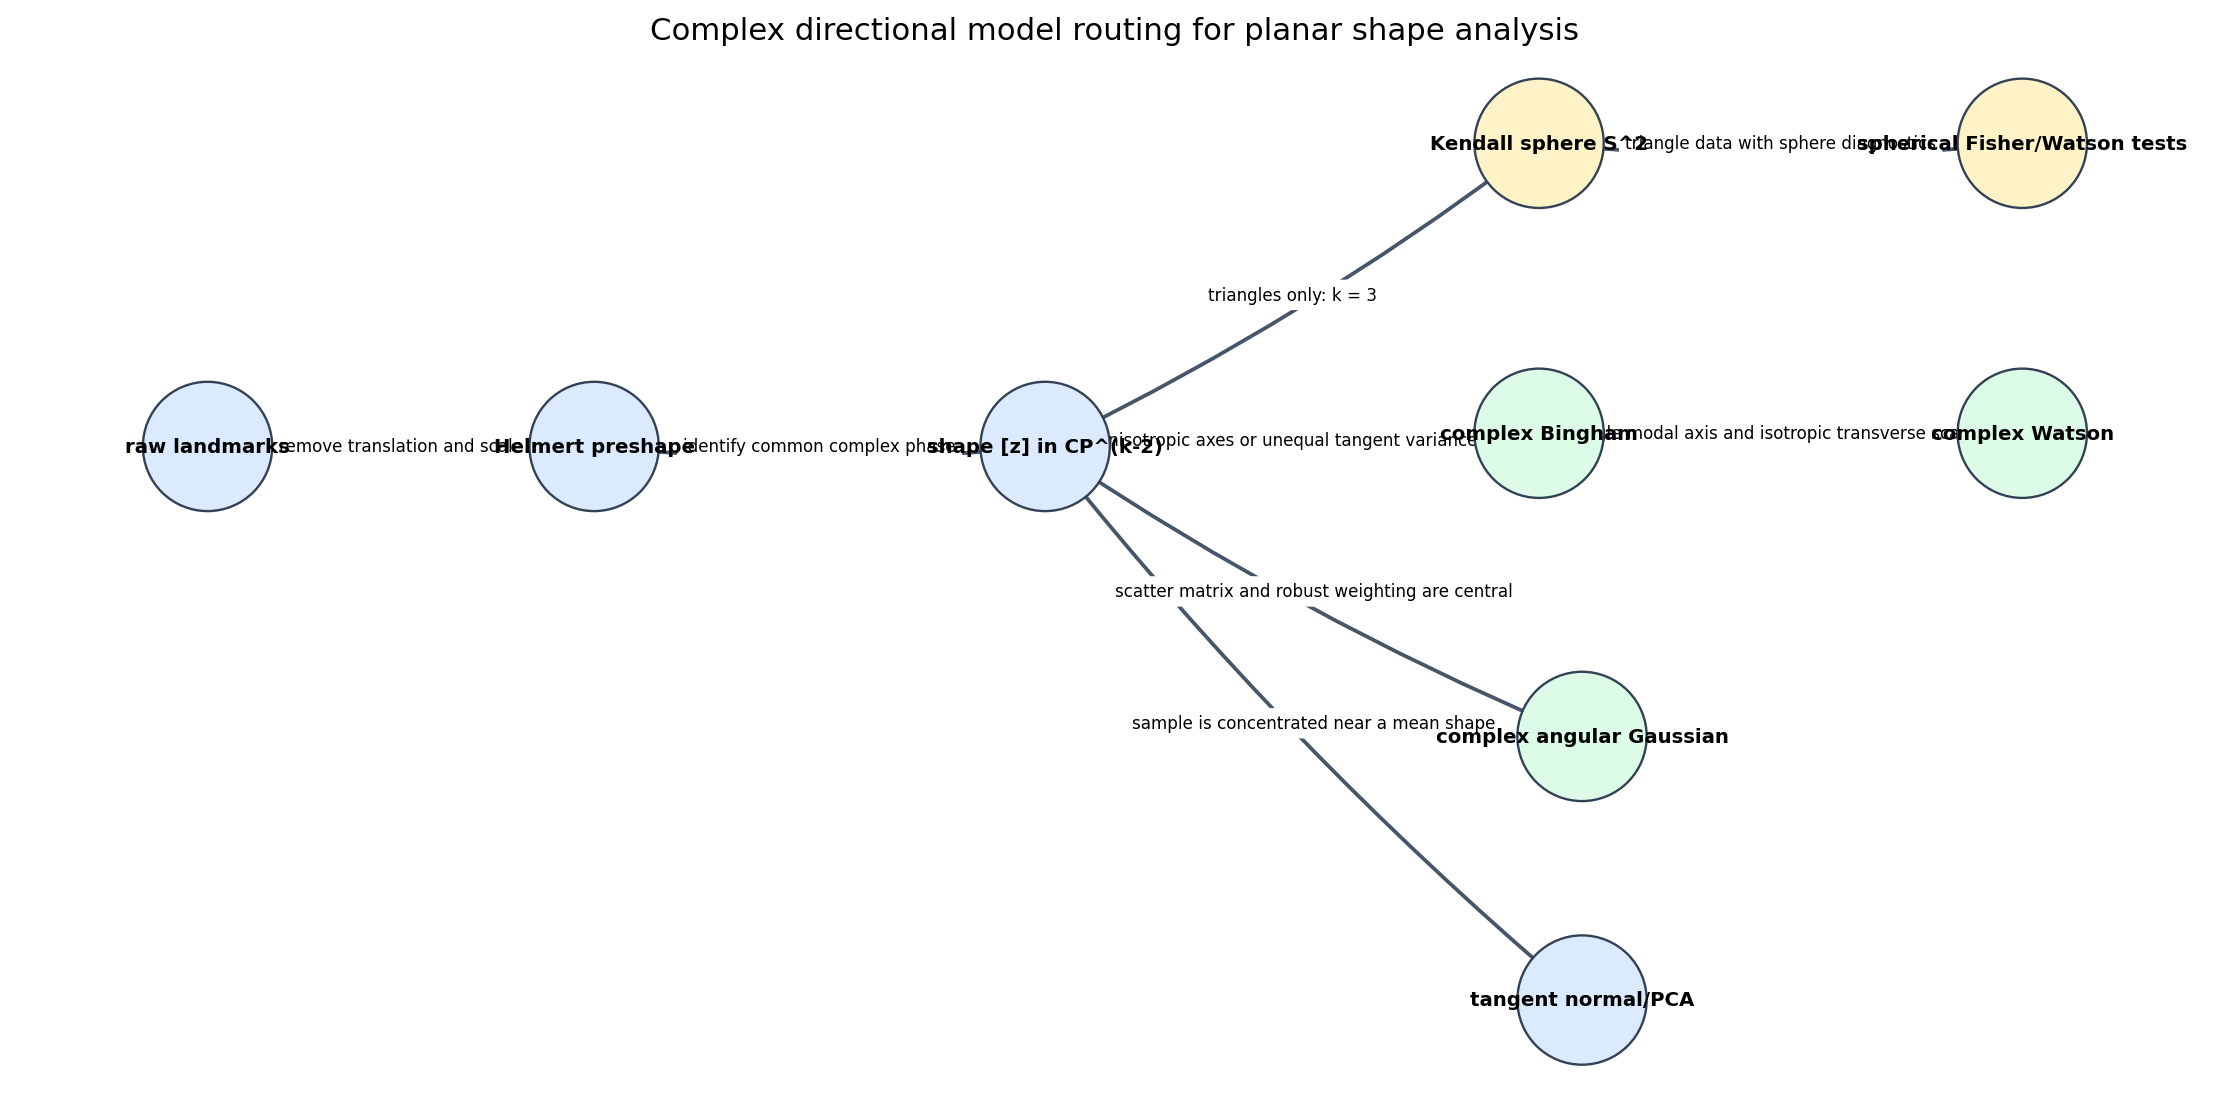

{'model_route_count': 8,
 'phase_invariant_models': ['complex Bingham',
  'complex Watson',
  'complex angular Gaussian'],
 'graph_has_triangle_sphere_route': True,
 'graph_has_tangent_route': True}

In [8]:
model_routes = [
    {"from": "raw landmarks", "to": "Helmert preshape", "condition": "remove translation and scale", "invariant": "H @ ones = 0; ||z|| = 1"},
    {"from": "Helmert preshape", "to": "shape [z] in CP^(k-2)", "condition": "identify common complex phase", "invariant": "f(z) = f(exp(i theta) z)"},
    {"from": "shape [z] in CP^(k-2)", "to": "Kendall sphere S^2", "condition": "triangles only: k = 3", "invariant": "Hopf coordinates have unit norm"},
    {"from": "shape [z] in CP^(k-2)", "to": "complex Bingham", "condition": "anisotropic axes or unequal tangent variances", "invariant": "quadratic form z* A z is phase invariant"},
    {"from": "complex Bingham", "to": "complex Watson", "condition": "single modal axis and isotropic transverse scatter", "invariant": "depends on cos^2 Procrustes angle"},
    {"from": "shape [z] in CP^(k-2)", "to": "complex angular Gaussian", "condition": "scatter matrix and robust weighting are central", "invariant": "density unchanged by positive scatter rescaling and phase"},
    {"from": "shape [z] in CP^(k-2)", "to": "tangent normal/PCA", "condition": "sample is concentrated near a mean shape", "invariant": "log vectors are horizontal to the mean"},
    {"from": "Kendall sphere S^2", "to": "spherical Fisher/Watson tests", "condition": "triangle data with sphere diagnostics", "invariant": "ordinary spherical rotations after Hopf map"},
]

G = nx.DiGraph()
for route in model_routes:
    G.add_edge(route["from"], route["to"], label=route["condition"])

positions = {
    "raw landmarks": (0, 2.2),
    "Helmert preshape": (1.8, 2.2),
    "shape [z] in CP^(k-2)": (3.9, 2.2),
    "Kendall sphere S^2": (6.2, 3.35),
    "spherical Fisher/Watson tests": (8.45, 3.35),
    "complex Bingham": (6.2, 2.25),
    "complex Watson": (8.45, 2.25),
    "complex angular Gaussian": (6.4, 1.1),
    "tangent normal/PCA": (6.4, 0.1),
}

fig, ax = plt.subplots(figsize=(13, 6.4), constrained_layout=True)
node_colors = []
for node in G.nodes:
    if "Kendall" in node or "spherical" in node:
        node_colors.append("#fef3c7")
    elif "complex" in node:
        node_colors.append("#dcfce7")
    else:
        node_colors.append("#dbeafe")
nx.draw_networkx_nodes(G, positions, node_color=node_colors, edgecolors="#334155", linewidths=1.0, node_size=3000, ax=ax)
nx.draw_networkx_labels(G, positions, font_size=8.4, font_weight="bold", ax=ax)
nx.draw_networkx_edges(G, positions, arrowstyle="-|>", arrowsize=18, width=1.6, edge_color="#475569", connectionstyle="arc3,rad=0.05", ax=ax)
nx.draw_networkx_edge_labels(G, positions, edge_labels=nx.get_edge_attributes(G, "label"), font_size=7.1, label_pos=0.50, rotate=False, ax=ax)
ax.set_title("Complex directional model routing for planar shape analysis", fontsize=13)
ax.set_axis_off()

model_routing_path = save_matplotlib(fig, TOPIC, "models", "complex-directional-model-routing.png", dpi=170)
plt.close(fig)
model_routing_json_path = save_json(model_routes, TOPIC, "models", "complex-directional-model-routing.json")
display_artifact(model_routing_path, width=980)

model_diagnostics = {
    "model_route_count": len(model_routes),
    "phase_invariant_models": ["complex Bingham", "complex Watson", "complex angular Gaussian"],
    "graph_has_triangle_sphere_route": nx.has_path(G, "shape [z] in CP^(k-2)", "spherical Fisher/Watson tests"),
    "graph_has_tangent_route": nx.has_path(G, "shape [z] in CP^(k-2)", "tangent normal/PCA"),
}
model_diagnostics


## Applied Lab: Stress The Invariants

The quickest way to misuse shape analysis is to compare raw coordinate arrays after a nuisance transformation has moved the drawing. The lab below applies different translations, scales, and rotations to two configurations, then repeats the same comparison in preshape and shape coordinates.

Change the translation, scale, or rotation values and rerun the cell. Raw Euclidean gaps should move around; Helmert, preshape, and Procrustes invariants should stay at numerical zero for true similarity transformations.


In [9]:
lab_a = base_shape
lab_b = center_complex(base_shape + 0.22 * deformation)
lab_a_seen = similarity_transform(lab_a, translation=4.0 - 0.5j, scale=1.9, rotation=2.3)
lab_b_seen = similarity_transform(lab_b, translation=-2.0 + 3.2j, scale=0.55, rotation=-0.7)

lab_za = preshape(lab_a, H8)
lab_zb = preshape(lab_b, H8)
lab_za_seen = preshape(lab_a_seen, H8)
lab_zb_seen = preshape(lab_b_seen, H8)

lab_checks = {
    "raw_centered_gap_changes_under_separate_similarity": float(abs(np.linalg.norm(center_complex(lab_a) - center_complex(lab_b)) - np.linalg.norm(center_complex(lab_a_seen) - center_complex(lab_b_seen)))),
    "shape_distance_original": procrustes_distance(lab_za, lab_zb),
    "shape_distance_after_separate_similarity": procrustes_distance(lab_za_seen, lab_zb_seen),
    "shape_distance_similarity_error": float(abs(procrustes_distance(lab_za, lab_zb) - procrustes_distance(lab_za_seen, lab_zb_seen))),
    "single_shape_translation_scale_rotation_error": float(procrustes_distance(lab_za, lab_za_seen)),
    "single_shape_preshape_norm_after_transform": float(np.linalg.norm(lab_za_seen)),
}
lab_checks


{'raw_centered_gap_changes_under_separate_similarity': 8.37626607693115,
 'shape_distance_original': 0.010194842367142427,
 'shape_distance_after_separate_similarity': 0.010194842367153316,
 'shape_distance_similarity_error': 1.0888859258706418e-14,
 'single_shape_translation_scale_rotation_error': 0.0,
 'single_shape_preshape_norm_after_transform': 1.0}

## Final Sanity Checks

The checks are part of the lesson. They verify that the visuals and computations refer to the same geometry:

- Helmert rows are orthonormal and remove translation.
- Preshapes have unit norm.
- Similarity transformations preserve shape and Procrustes distance.
- Kendall triangle coordinates stay on the sphere and ignore phase.
- Tangent vectors are horizontal to the Procrustes mean.
- All concept-named artifacts exist and have nonzero size.


In [10]:
all_artifact_paths = [
    pipeline_path,
    procrustes_path,
    shape_sphere_path,
    tangent_path,
    model_routing_path,
    model_routing_json_path,
]
artifact_records = assert_artifacts(all_artifact_paths, min_bytes=500)

numeric_checks = {
    "source_span": source_span,
    "helmert": helmert_diagnostics,
    "procrustes": procrustes_diagnostics,
    "shape_sphere": shape_sphere_diagnostics,
    "tangent_pca": tangent_diagnostics,
    "model_routing": model_diagnostics,
    "lab": lab_checks,
    "artifact_records": artifact_records,
}

assert numeric_checks["helmert"]["helmert_orthogonality_error"] < 1e-12
assert numeric_checks["helmert"]["helmert_translation_error"] < 1e-12
assert abs(numeric_checks["helmert"]["base_preshape_norm"] - 1.0) < 1e-12
assert numeric_checks["helmert"]["max_similarity_shape_distance"] < 1e-7
assert numeric_checks["procrustes"]["procrustes_distance_invariance_error"] < 1e-12
assert numeric_checks["procrustes"]["aligned_inner_product_imag_abs"] < 1e-12
assert numeric_checks["shape_sphere"]["max_kendall_sphere_norm_error"] < 1e-12
assert numeric_checks["shape_sphere"]["hopf_phase_invariance_error"] < 1e-12
assert numeric_checks["tangent_pca"]["max_tangent_orthogonality_abs"] < 1e-10
assert numeric_checks["lab"]["shape_distance_similarity_error"] < 1e-12
assert numeric_checks["lab"]["single_shape_translation_scale_rotation_error"] < 1e-7
assert all(record["exists"] and record["bytes"] > 500 for record in artifact_records)

checks_path = save_json(numeric_checks, TOPIC, "checks", "shape-analysis-invariants.json")
final_sanity = {
    "chapter": "14 Shape Analysis",
    "source_used_for": "orientation only",
    "source_span": source_span,
    "checks_path": str(checks_path.relative_to(BOOK_ROOT)).replace("\\", "/"),
    "all_checks_passed": True,
    "artifact_count": len(artifact_records),
    "max_similarity_shape_distance": numeric_checks["helmert"]["max_similarity_shape_distance"],
    "max_tangent_orthogonality_abs": numeric_checks["tangent_pca"]["max_tangent_orthogonality_abs"],
}
final_path = save_json(final_sanity, TOPIC, "checks", "final-sanity.json")
assert_artifacts([checks_path, final_path], min_bytes=100)
final_sanity


{'chapter': '14 Shape Analysis',
 'source_used_for': 'orientation only',
 'source_span': {'printed_pages': '303-348', 'pdf_pages': '317-361'},
 'checks_path': 'artifacts/chapter-14/checks/shape-analysis-invariants.json',
 'all_checks_passed': True,
 'artifact_count': 6,
 'max_similarity_shape_distance': 1.4901161193847656e-08,
 'max_tangent_orthogonality_abs': 2.945992578940396e-16}

## Takeaways

Shape analysis is directional statistics after a sequence of quotient operations. Centering and Helmertization remove location. Normalizing removes scale. The remaining common complex phase records planar rotation and is removed by working with the shape class `[z]`.

For triangles, the quotient is especially visible because `CP^1` can be drawn as a sphere. For larger planar landmark sets, the same principle remains: use phase-invariant distances and models on complex projective shape space, then use tangent coordinates only when the sample is concentrated enough for a local linear approximation.

The final JSON checks are intentionally concrete. If one of them fails, the notebook is no longer teaching shape analysis; it is just plotting coordinates.
